In [305]:
from matplotlib.ticker import StrMethodFormatter
import pandas as pd
import numpy as np
import json
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch

d3_colors = [
    "#1F77B4",
    "#FF7F0E",
    "#2CA02C",
    "#D62728",
    "#9467BD",
    "#8C564B",
    "#E377C2",
    "#7F7F7F",
    "#BCBD22",
    "#17BECF",
]
# Set the default style for the Matplotlib plots
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": "CMU Serif",
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}",
        "font.size": 12,
        "font.weight": "normal",
        "figure.titlesize": "medium",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "savefig.dpi": 300,
        "figure.dpi": 150,
        "savefig.bbox": "tight",
    }
)

# Define colors for each group with penta/mmr
# colors = {
#     "MMR Antigens": d3_colors[0],
#     "MMR": d3_colors[1],
#     "Hexa Antigens": d3_colors[2],
#     "Penta": d3_colors[3],
#     "HPV": d3_colors[4],
#     "PCV": d3_colors[5],
#     "Rota": d3_colors[6],
# }

# Define colors for each group with penta/mmr
colors = {
    "MMR Antigens": "C0",
    "MMR": "C1",
    "Hexa Antigens": "C2",
    "Penta": "C3",
    "HPV": "C4",
    "PCV": "C5",
    "Rota": "C6",
}

color_groups = {
    "MMR Antigens": ["Measles", "Mumps", "Rubella"],
    "MMR": ["MMR"],
    "Hexa Antigens": ["Diphtheria", "Tetanus", "Pertussis", "Hib", "Polio", "Hepatitis_B"],
    "Penta": ["Penta"],
    "HPV": ["HPV"],
    "PCV": ["PCV"],
    "Rota": ["Rotavirus"],
}
antigen_colors = {antigen: colors[color] for color, antigens in color_groups.items() for antigen in antigens}
antigen_groups = {antigen: group for group, antigens in color_groups.items() for antigen in antigens}


def add_grid(ax, grid_axis: str = "both", thousand_sep: bool = False, include_legend: bool = False):
    ax.set_axisbelow(True)
    ax.grid(True, which="both", axis=grid_axis, ls="--", c="0.8")
    ax.spines.right.set_visible(False)
    ax.spines.top.set_visible(False)
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}")) if thousand_sep else None
    (
        ax.legend(loc="best", fancybox=True, framealpha=1, borderpad=0.5, facecolor="white", fontsize=10)
        if include_legend
        else None
    )


# Function to add 1 if value is smaller than 10
def add_one_if_smaller_than_10(value):
    if value < 10:
        return value + 1
    return value

- Keys in JSON files:
  - dict_keys(['Y', 'Q', 'I', 'W', 'X', 'S', 'L', 'Vc', 'F'])
- $F_{a,t,\tau}$: binary, tender schedule
- $L_{p,t}$: integer (btw 0 and 5), capacity extension level ($p$ is the producer)
- $S_{a,t,\omega}$: continuous, unvaccinated children


In [39]:
temp_path = "/Users/htbui/Active Projects/Vaccine Tender/Github/Vaccine_Tender/DATA/temporary/DE_L_results_T_10_delta_5_scen_21_trial_1_inv_2_cap._1_cap.inc._5.json"
# Read the json file
with open(temp_path, "r") as read_file:
    data = json.load(read_file)

omega_prob = {
    1: 0.0563993921466784,
    2: 0.0422612944476887,
    3: 0.0440657500980449,
    4: 0.0329201603015805,
    5: 0.0160898586108595,
    6: 0.0422612944476887,
    7: 0.0160898586108595,
    8: 0.0422612944476887,
    9: 0.0551813981376962,
    10: 0.0422612944476887,
    11: 0.0329201603015805,
    12: 0.0440657500980449,
    13: 0.0422612944476887,
    14: 0.0329201603015805,
    15: 0.0398167747700248,
    16: 0.0422612944476887,
    17: 0.0422612944476887,
    18: 0.0563993921466784,
    19: 0.0551813981376962,
    20: 0.0563993921466784,
    21: 0.0008685203064207,
    22: 0.0011340439389191,
    23: 0.001159075177165,
    24: 0.0011340439389191,
    25: 0.0009056040350394,
    26: 0.0009056040350394,
    27: 0.0006765487921327,
    28: 0.0009056040350394,
    29: 0.0006765487921327,
    30: 0.0006765487921327,
    31: 0.0009056040350394,
    32: 0.0009056040350394,
    33: 0.0009056040350394,
    34: 0.0009056040350394,
    35: 0.0011340439389191,
    36: 0.0006765487921327,
    37: 0.001159075177165,
    38: 0.0008182824940858,
    39: 0.0008182824940858,
    40: 0.001159075177165,
    41: 0.0013007380686335,
    42: 0.001802671001172,
    43: 0.0014395439863343,
    44: 0.0013805958628076,
    45: 0.0013007380686335,
    46: 0.0005256249843176,
    47: 0.001802671001172,
    48: 0.0018424605417363,
    49: 0.0010754388314248,
    50: 0.0013007380686335,
    51: 0.0013805958628076,
    52: 0.0005256249843176,
    53: 0.0018424605417363,
    54: 0.0013007380686335,
    55: 0.0018424605417363,
    56: 0.0013007380686335,
    57: 0.0014395439863343,
    58: 0.0013805958628076,
    59: 0.001802671001172,
    60: 0.0014395439863343,
    61: 0.005212488368985,
    62: 0.005212488368985,
    63: 0.0040726008049749,
    64: 0.0036799062450795,
    65: 0.0039058312045975,
    66: 0.0040726008049749,
    67: 0.0040726008049749,
    68: 0.0050999201414977,
    69: 0.0050999201414977,
    70: 0.0036799062450795,
    71: 0.0012730433744906,
    72: 0.0030425142212674,
    73: 0.0040726008049749,
    74: 0.005212488368985,
    75: 0.0050999201414977,
    76: 0.0040726008049749,
    77: 0.005212488368985,
    78: 0.0036799062450795,
    79: 0.0039058312045975,
    80: 0.005212488368985,
    81: 0.0001540966998543,
    82: 4.396136232475273e-05,
    83: 8.994579317371724e-05,
    84: 0.0001154680176166,
    85: 0.0001507688473707,
    86: 0.0001540966998543,
    87: 8.994579317371724e-05,
    88: 0.0001507688473707,
    89: 0.0001154680176166,
    90: 1.2552796967194154e-05,
    91: 0.0001507688473707,
    92: 0.0001154680176166,
    93: 0.0001203982243115,
    94: 0.0001087890021038,
    95: 0.0001154680176166,
    96: 0.0001540966998543,
    97: 4.396136232475273e-05,
    98: 0.0001507688473707,
    99: 0.0001154680176166,
    100: 0.0001203982243115,
    101: 0.0002268198262641,
    102: 0.0003885916778934,
    103: 0.0003801997020653,
    104: 0.0002911802183376,
    105: 0.0003801997020653,
    106: 0.0002911802183376,
    107: 0.0003885916778934,
    108: 9.490554719852948e-05,
    109: 0.0003801997020653,
    110: 0.0003801997020653,
    111: 0.0002743374835663,
    112: 0.0003036129134814,
    113: 0.0003801997020653,
    114: 0.0002743374835663,
    115: 0.0003885916778934,
    116: 0.0003036129134814,
    117: 0.0002743374835663,
    118: 0.0002268198262641,
    119: 0.0003801997020653,
    120: 9.490554719852948e-05,
    121: 0.0018424605417363,
    122: 0.0010754388314248,
    123: 0.0014395439863343,
    124: 0.0005256249843176,
    125: 0.001802671001172,
    126: 0.001802671001172,
    127: 0.0005256249843176,
    128: 0.0014395439863343,
    129: 0.0014395439863343,
    130: 0.0010754388314248,
    131: 0.0013007380686335,
    132: 0.000449983197924,
    133: 0.0013805958628076,
    134: 0.0010754388314248,
    135: 0.0018424605417363,
    136: 0.0013805958628076,
    137: 0.0013007380686335,
    138: 0.0010754388314248,
    139: 0.0018424605417363,
    140: 0.0013805958628076,
}

In [468]:
F_temp, L_temp, S_temp = [], [], []
for antigen, t_dict in data["F"].items():
    for t, tau_dict in t_dict.items():
        for tau, val in tau_dict.items():
            F_temp.append([antigen, t, tau, int(val)]) if val != 0 else None

for producer, t_dict in data["L"].items():
    for t, val in t_dict.items():
        L_temp.append([producer, t, val])

for antigen, t_dict in data["S"].items():
    for t, omega_dict in t_dict.items():
        for omega, val in omega_dict.items():
            S_temp.append([antigen, t, omega, val])

F_df = pd.DataFrame(F_temp, columns=["antigen", "t", "tau", "val"])
# Add the antigen group
F_df["antigen_group"] = F_df["antigen"].map(antigen_groups)
L_df = pd.DataFrame(L_temp, columns=["producer", "t", "val"])
S_df = pd.DataFrame(S_temp, columns=["antigen", "t", "omega", "val"])
# Convert multiple columns to numeric
F_df[["t", "tau", "val"]] = F_df[["t", "tau", "val"]].apply(pd.to_numeric)
L_df[["t", "val"]] = L_df[["t", "val"]].apply(pd.to_numeric)
S_df[["t", "omega", "val"]] = S_df[["t", "omega", "val"]].apply(pd.to_numeric)
# Sort the dataframe
F_df = F_df.sort_values(by=["antigen_group", "antigen", "t", "tau"]).reset_index(drop=True)
L_df = L_df.sort_values(by=["producer", "t"]).reset_index(drop=True)
S_df = S_df.sort_values(by=["antigen", "t", "omega"]).reset_index(drop=True)

# F_df["adj_tau"] = F_df["tau"].apply(add_one_if_smaller_than_10)
F_df["adj_t"] = F_df["t"] - 1

# Get the omega probability used in the results
omega_prob_used = {i: omega_prob[i] for i in S_df["omega"].unique()}
# Scaled the omega probability to sum to 1
omega_prob_used = {k: v / sum(omega_prob_used.values()) for k, v in omega_prob_used.items()}
omega_prob_used

# Add the probability of omega
S_df["omega_prob"] = S_df["omega"].map(omega_prob_used)

# Plot Vaccine Tender Schedule ($F$)


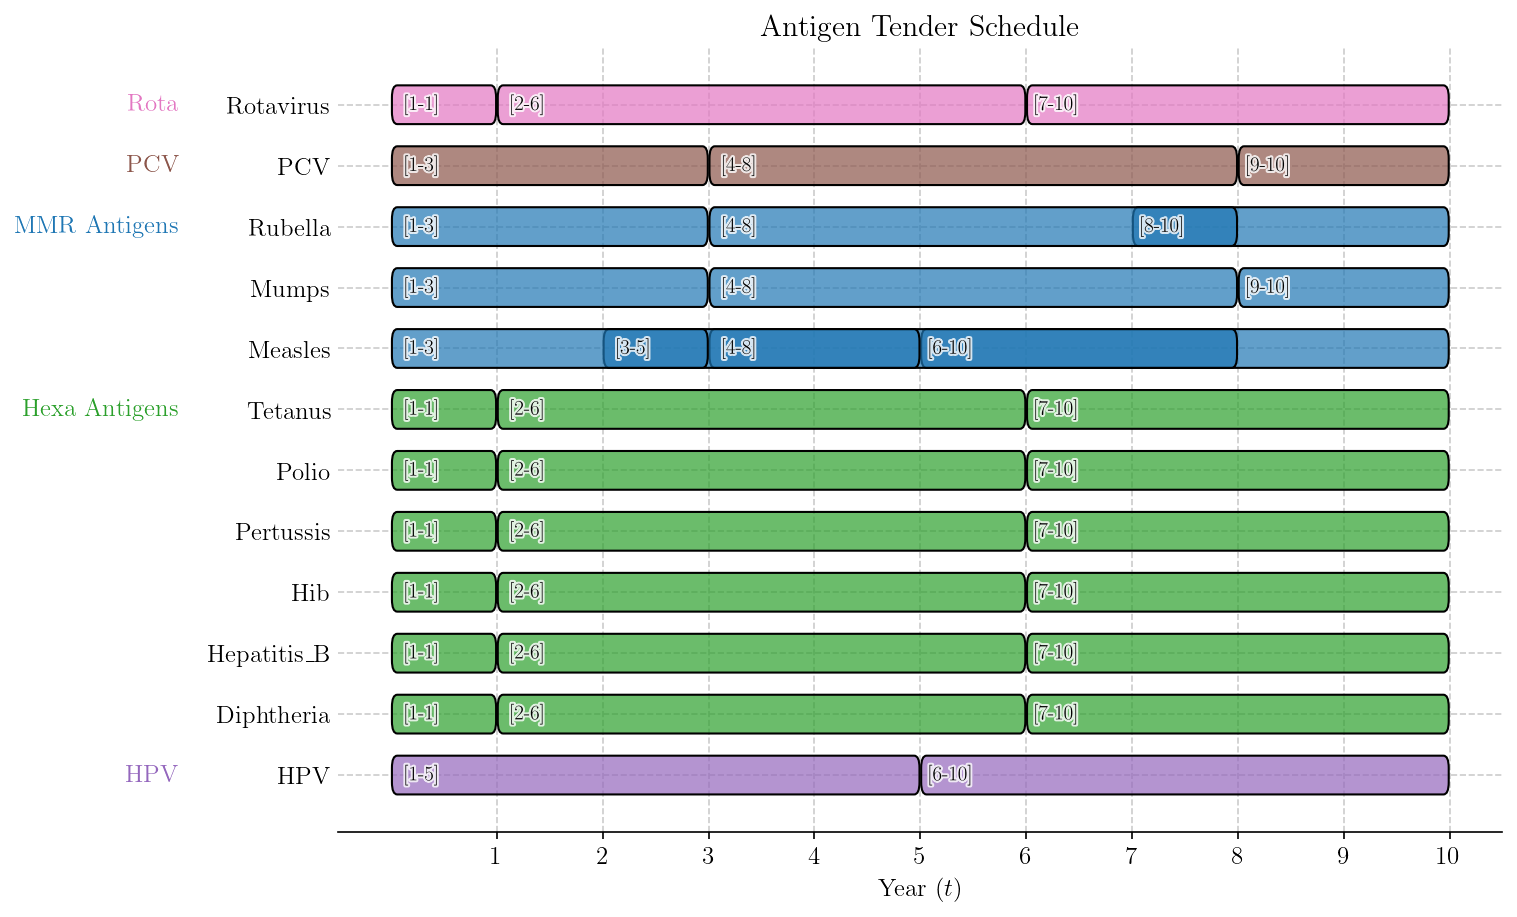

In [357]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6), layout="constrained")

axis_groups = []
label_groups = []
y = -1

for group, group_df in F_df.groupby("antigen_group"):
    for antigen, df in group_df.groupby("antigen"):
        for idx, row in df.iterrows():
            width = row["tau"] - row["adj_t"]
            ax.barh(
                y=antigen,
                width=width,
                height=0.7,
                left=row["adj_t"],
                facecolor=antigen_colors[antigen],
                alpha=0.7,
            )

            # Add the text
            ax.text(
                x=row["adj_t"] + 0.3,
                y=antigen,
                s=f"[{row["t"]}-{row["tau"]}]",
                ha="center",
                va="center",
                color="black",
                fontsize=10,
                path_effects=[path_effects.withStroke(linewidth=2, foreground="white", capstyle="round", joinstyle="round", alpha=0.8)],
            )
        y+=1
    label_groups.append(group)
    axis_groups.append(y)

# Make the bar rounded
new_patches = []
for patch in reversed(ax.patches):
    bb = patch.get_bbox()
    color=patch.get_facecolor()
    p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),
                        abs(bb.width), abs(bb.height),
                        boxstyle="round,pad=-0.008,rounding_size=0.05",
                        ec="black", fc=color,
                        mutation_aspect=4
                        )
    patch.remove()
    new_patches.append(p_bbox)
for patch in new_patches:
    ax.add_patch(patch)

ax.set_title("Antigen Tender Schedule")
ax.set_xlabel("Year ($t$)")
ax.tick_params(axis="y", length=0)
ax.spines.left.set_visible(False)
ax.xaxis.set_ticks(np.arange(1, 10+1))

for i, j in zip(axis_groups, label_groups):
    ax.text( -2, i, j, ha='right', va="center", color=colors[j], weight="bold")

# Format the axes
add_grid(ax)
fig.savefig("../visualization/antigen_tender_schedule.png", dpi=600)

# Plot capacity expansion level ($L$)


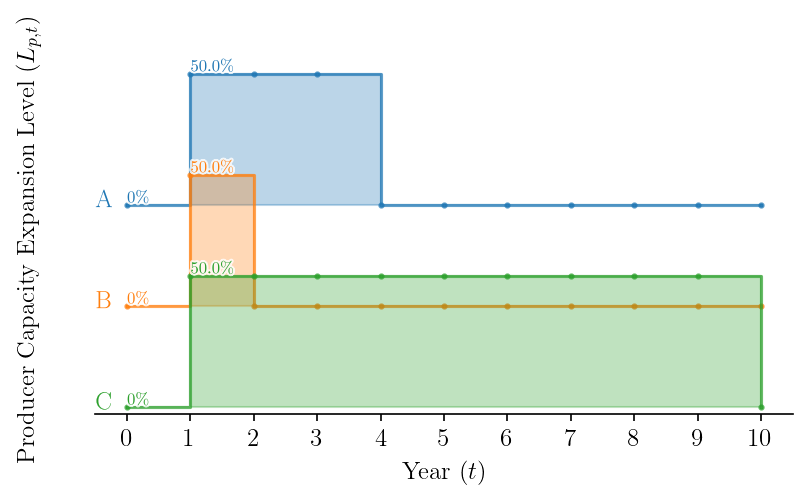

In [445]:
import matplotlib.gridspec as grid_spec

# Only filter out the producers with non-zero values
producers = L_df.groupby("producer").sum().query("val != 0").index
n_producers = len(producers)
filter_L_df = L_df[L_df["producer"].isin(producers)].reset_index(drop=True)
spines = ["top", "right", "left", "bottom"]
gs = grid_spec.GridSpec(n_producers, 1)
fig = plt.figure(figsize=(6, n_producers * 1))

i = 0
abc = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
# creating empty list
ax_objs = []

for idx, (producer, df) in enumerate(filter_L_df.groupby("producer")):
    ax = fig.add_subplot(gs[i, 0])
    val = np.insert(df["val"].values * 10, 0, 0)
    first_max_idx = np.argmax(val)
    ts = np.arange(10 + 1)

    ax.step(ts, val, marker="o", color=d3_colors[idx], alpha=0.7, where="post", markersize=2)
    ax.fill_between(ts, val, color=d3_colors[idx], alpha=0.3, step="post")
    # make background transparent
    rect = ax.patch
    rect.set_alpha(0)

    spines = ["top", "right", "left", "bottom"]
    for s in spines:
        ax.spines[s].set_visible(False)
    if i == filter_L_df["producer"].nunique() - 1:
        ax.spines["bottom"].set_visible(True)
        ax.xaxis.set_ticks(np.arange(0, 10 + 1, 1))
        ax.set_xlabel("Year ($t$)")
        ax.tick_params(axis="y", length=0)
    else:
        ax.set_xticklabels([])
        ax.tick_params(axis="both", length=0)

    ax.set_yticklabels([])
    ax.tick_params(axis="y", length=0)
    ax.yaxis.set_ticks(np.arange(0, 50 + 1, 10))
    ax_objs.append(ax)

    ax.text(
        0,
        0,
        abc[idx],
        ha="left",
        va="bottom",
        rotation=0,
        transform=ax.transAxes,
        color=d3_colors[idx],
        path_effects=[
            path_effects.withStroke(linewidth=2, foreground="white", capstyle="round", joinstyle="round", alpha=0.8)
        ],
    )

    ax.text(
        first_max_idx,
        val[first_max_idx],
        f"{val[first_max_idx]}%",
        ha="left",
        va="bottom",
        fontsize=8,
        usetex=False,
        color=d3_colors[idx],
        path_effects=[
            path_effects.withStroke(linewidth=2, foreground="white", capstyle="round", joinstyle="round", alpha=0.8)
        ],
    )

    ax.text(
        0,
        0,
        f"0%",
        ha="left",
        va="bottom",
        fontsize=8,
        usetex=False,
        color=d3_colors[idx],
        path_effects=[
            path_effects.withStroke(linewidth=2, foreground="white", capstyle="round", joinstyle="round", alpha=0.8)
        ],
    )

    i += 1

plt.text(
    0.05,
    0.5,
    "Producer Capacity Expansion Level  ($L_{p,t}$)",
    ha="center",
    va="center",
    rotation=90,
    fontsize=12,
    transform=fig.transFigure,
)
gs.update(hspace=-0.3)
fig.savefig("../visualization/producer_capacity_expansion_v2.png", dpi=600, bbox_inches="tight")

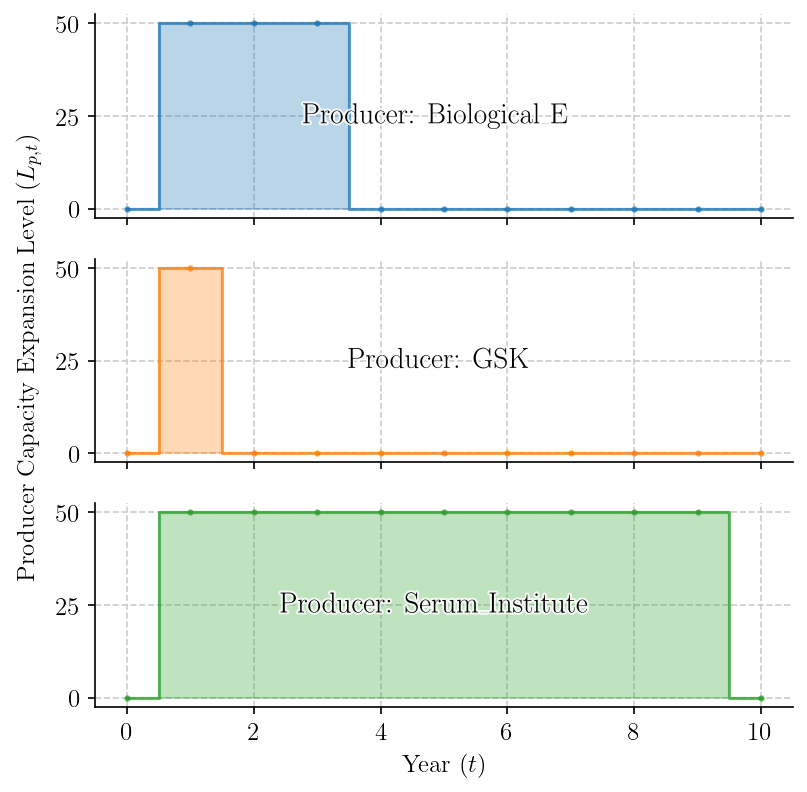

In [398]:
import matplotlib.gridspec as grid_spec

# Only filter out the producers with non-zero values
producers = L_df.groupby("producer").sum().query("val != 0").index
n_producers = len(producers)
filter_L_df = L_df[L_df["producer"].isin(producers)].reset_index(drop=True)
fig, axes = plt.subplots(n_producers, 1, figsize=(6, n_producers * 2), sharex=True)
axes = axes.flatten()

for idx, (producer, df) in enumerate(filter_L_df.groupby("producer")):
    ax = axes[idx]
    val = np.insert(df["val"].values * 10, 0, 0)
    ts = np.arange(10 + 1)

    ax.step(ts, val, marker="o", color=d3_colors[idx], alpha=0.7, where="mid", markersize=2)
    ax.fill_between(ts, val, color=d3_colors[idx], alpha=0.3, step="mid")

    ax.yaxis.set_ticks(np.arange(0, 50 + 1, 25))
    add_grid(ax)
    # ax.set_title(f"Producer: {producer}")
    ax.text(
        0.5,
        0.5,
        f"Producer: {producer}",
        ha="center",
        va="center",
        fontsize=14,
        weight="bold",
        transform=ax.transAxes,
        path_effects=[
            path_effects.withStroke(linewidth=2, foreground="white", capstyle="round", joinstyle="round", alpha=0.8)
        ],
    )

ax.set_xlabel("Year ($t$)")
plt.text(
    0.05,
    0.5,
    "Producer Capacity Expansion Level  ($L_{p,t}$)",
    ha="center",
    va="center",
    rotation=90,
    fontsize=12,
    transform=fig.transFigure,
)

fig.savefig("../visualization/producer_capacity_expansion.png", dpi=600, bbox_inches="tight")

# Unvaccinated Children ($S$)

In [485]:
antigen_colors

{'Measles': 'C0',
 'Mumps': 'C0',
 'Rubella': 'C0',
 'MMR': 'C1',
 'Diphtheria': 'C2',
 'Tetanus': 'C2',
 'Pertussis': 'C2',
 'Hib': 'C2',
 'Polio': 'C2',
 'Hepatitis_B': 'C2',
 'Penta': 'C3',
 'HPV': 'C4',
 'PCV': 'C5',
 'Rotavirus': 'C6'}

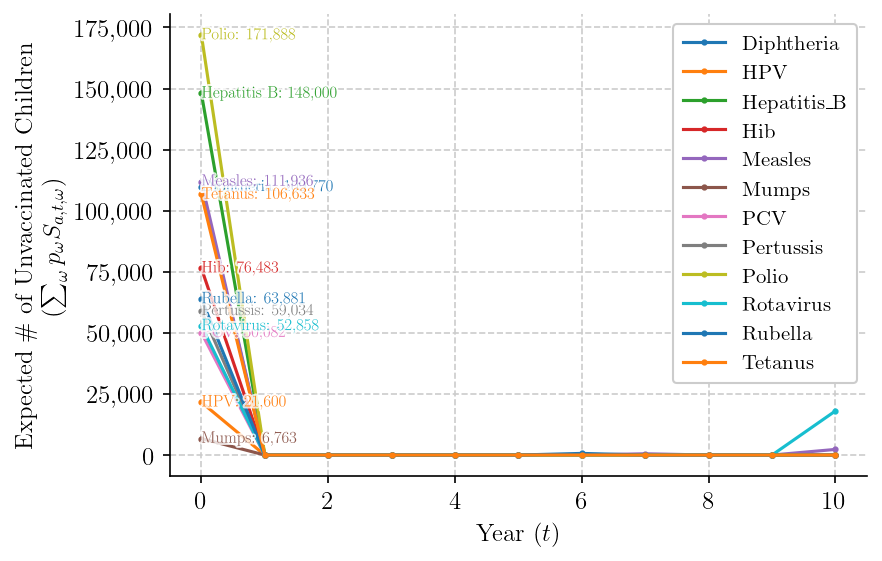

In [498]:
antigens = S_df["antigen"].unique()

# Calculate the expected value of each antigen for each year
S_df["expected_val"] = S_df["val"] * S_df["omega_prob"]
S_agg_df = S_df.groupby(["antigen", "t"]).agg({"expected_val": "sum"}).reset_index()

fig, ax = plt.subplots(1, 1, figsize=(6, 4), sharex=True)
for idx, (antigen, df) in enumerate(S_agg_df.groupby("antigen")):
    y_vals = df["expected_val"].values
    ax.plot(df["t"], y_vals, label=antigen, color=f"C{idx}", marker="o", markersize=2)
    # add the text at year 0
    ax.text(
        0,
        y_vals[0],
        f"{antigen}: {y_vals[0]:,.0f}",
        ha="left",
        va="center",
        color=f"C{idx}",
        fontsize=8,
        weight="bold",
        path_effects=[
            path_effects.withStroke(linewidth=2, foreground="white", capstyle="round", joinstyle="round", alpha=0.8)
        ],
    )
ax.set_xlabel("Year ($t$)")
ax.set_ylabel("Expected \\# of Unvaccinated Children\n($\\sum_{\\omega} p_{\\omega}S_{a,t,\\omega}$)")
add_grid(ax, thousand_sep=True, include_legend=True)
fig.savefig("../visualization/expected_unvaccinated_children.png", dpi=600, bbox_inches="tight")